
Processing: Underexposed


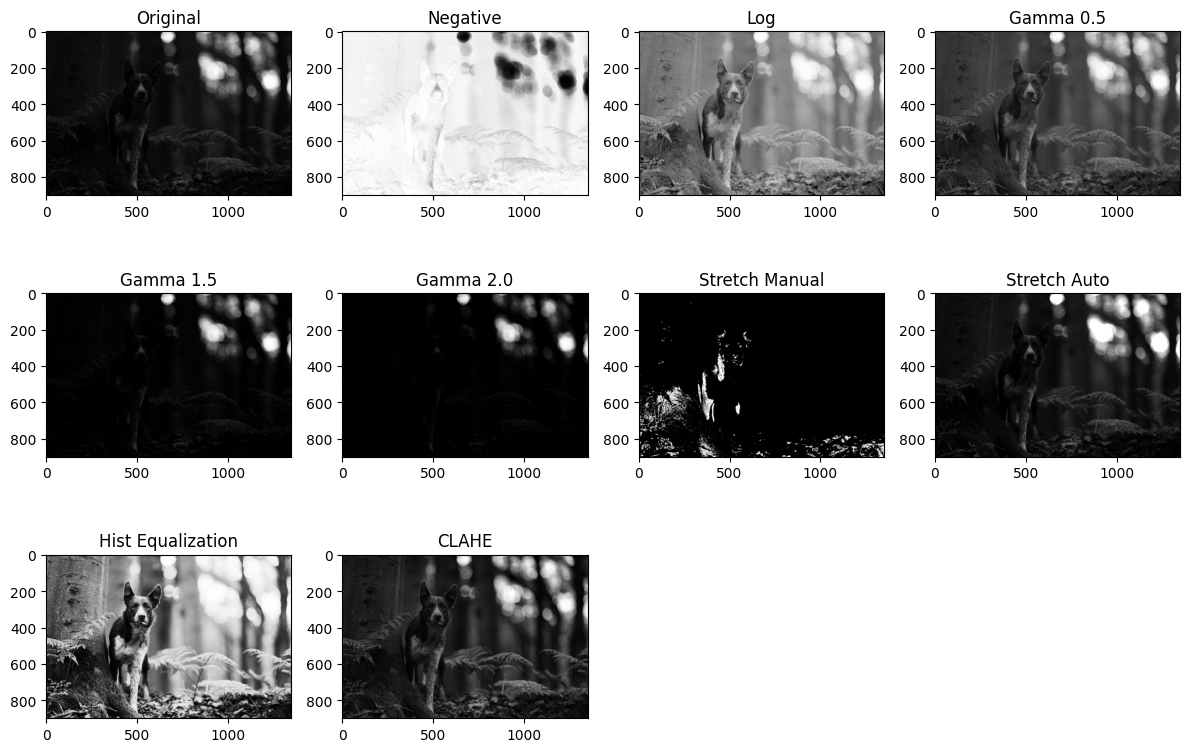

C:\Users\LOQ\AppData\Local\Temp\ipykernel_4512\2485277169.py:156: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.ravel(),256,[0,256])
C:\Users\LOQ\AppData\Local\Temp\ipykernel_4512\2485277169.py:160: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(clahe_img.ravel(),256,[0,256])


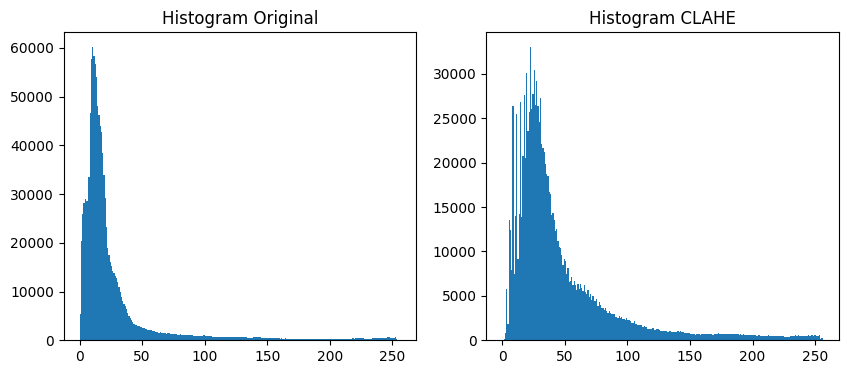

Contrast Ratio (Original): 254
Contrast Ratio (CLAHE): 255
Entropy (Original): 5.925458340404891
Entropy (CLAHE): 6.764848661815995

Processing: Overexposed


C:\Users\LOQ\AppData\Local\Temp\ipykernel_4512\2485277169.py:29: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
C:\Users\LOQ\AppData\Local\Temp\ipykernel_4512\2485277169.py:29: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))
C:\Users\LOQ\AppData\Local\Temp\ipykernel_4512\2485277169.py:30: RuntimeWarning: divide by zero encountered in log
  log_img = c * np.log(1 + img)
C:\Users\LOQ\AppData\Local\Temp\ipykernel_4512\2485277169.py:30: RuntimeWarning: invalid value encountered in multiply
  log_img = c * np.log(1 + img)
C:\Users\LOQ\AppData\Local\Temp\ipykernel_4512\2485277169.py:31: RuntimeWarning: invalid value encountered in cast
  return np.array(log_img, dtype=np.uint8)


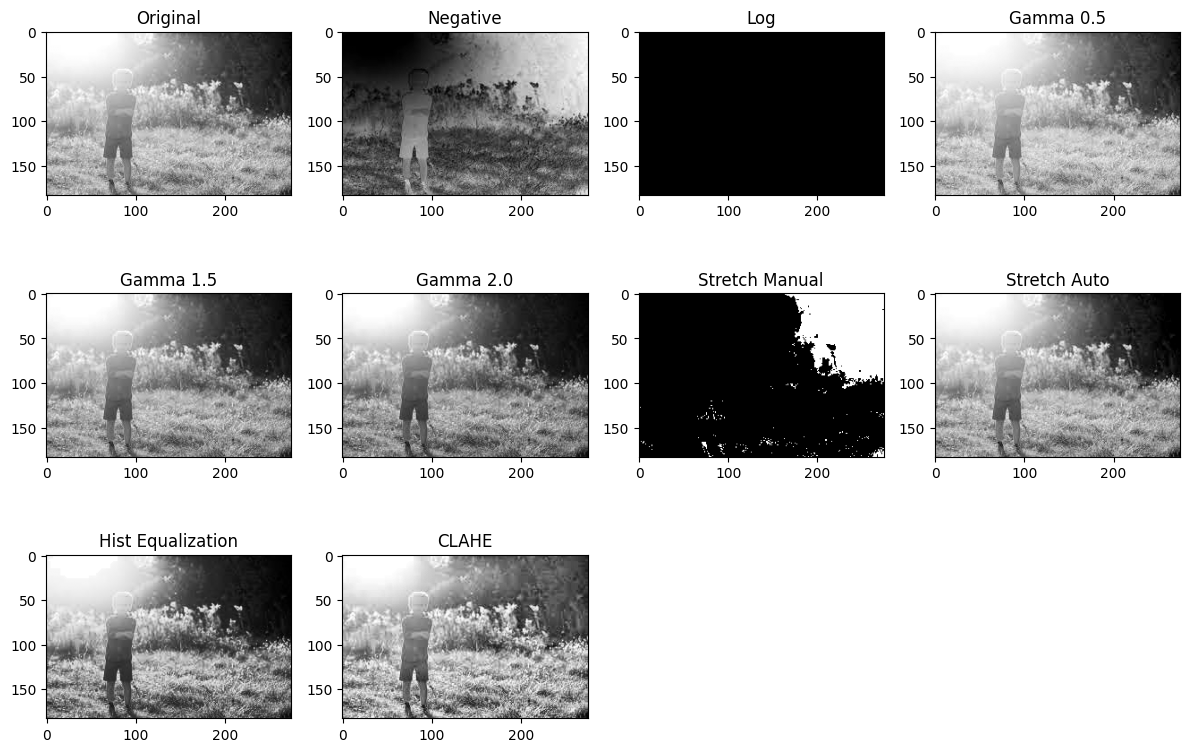

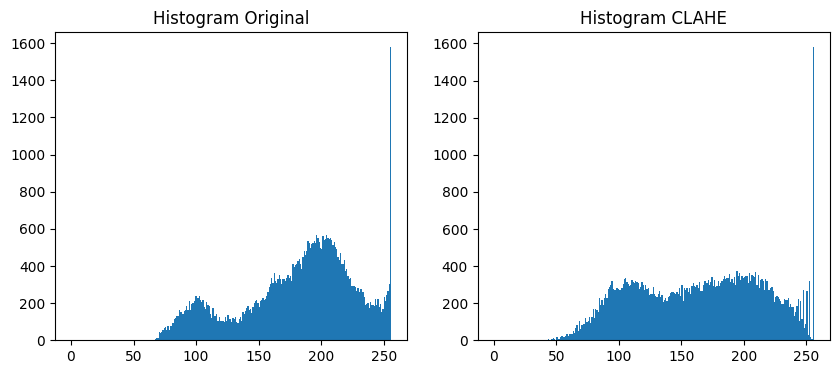

Contrast Ratio (Original): 190
Contrast Ratio (CLAHE): 229
Entropy (Original): 7.293734276682342
Entropy (CLAHE): 7.494779739713447

Processing: Uneven Illumination


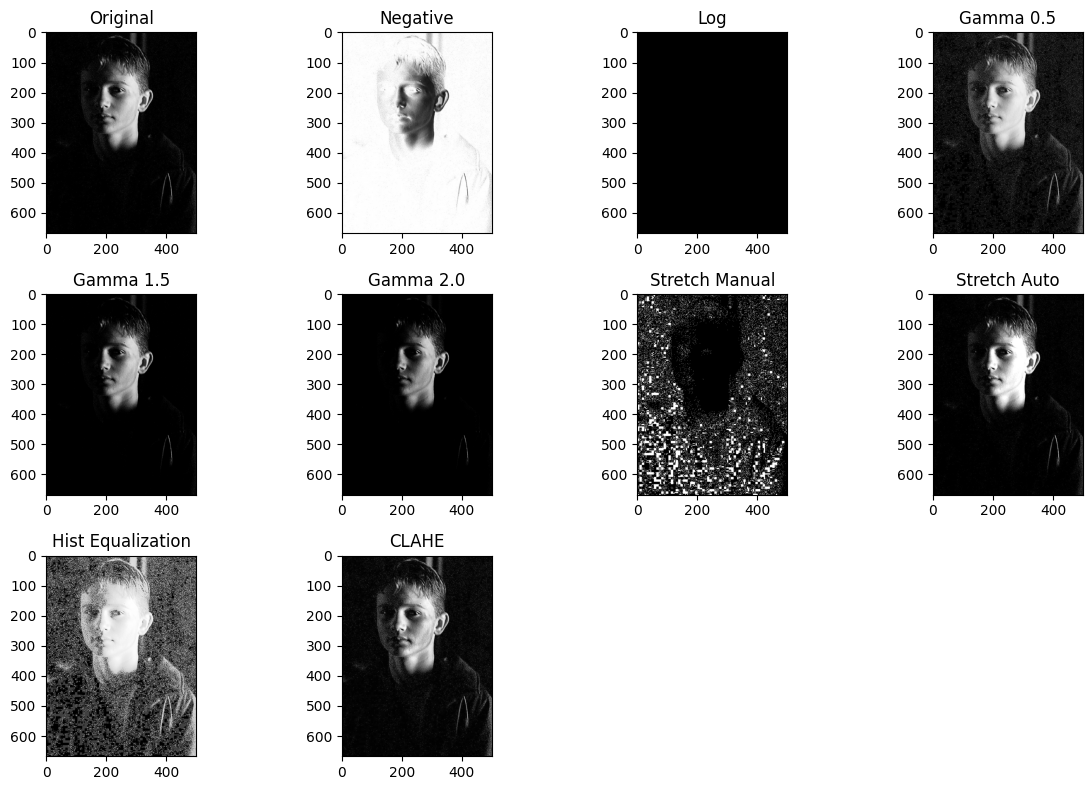

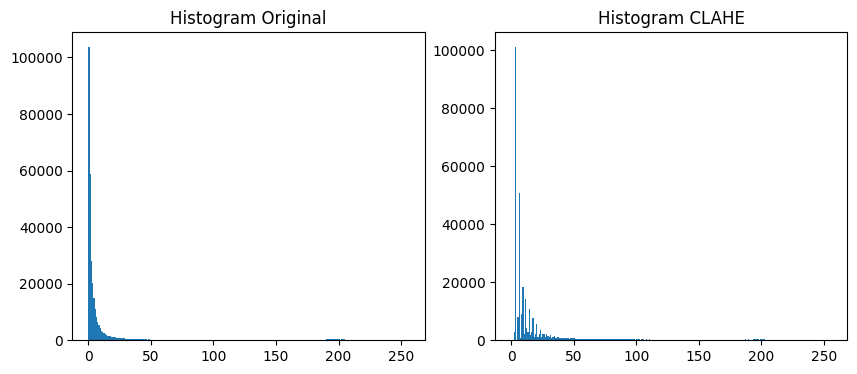

Contrast Ratio (Original): 255
Contrast Ratio (CLAHE): 254
Entropy (Original): 4.350285397588217
Entropy (CLAHE): 4.898479963512635


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import shannon_entropy

# ===============================
# 1. Load Images
# ===============================

underexposed = cv2.imread("underexposed.jpg", 0)
overexposed = cv2.imread("overexposed.jpg", 0)
uneven = cv2.imread("uneven.jpg", 0)

images = {
    "Underexposed": underexposed,
    "Overexposed": overexposed,
    "Uneven Illumination": uneven
}

# ===============================
# 2. Point Processing
# ===============================

def negative_transformation(img):
    return 255 - img


def log_transformation(img):
    c = 255 / np.log(1 + np.max(img))
    log_img = c * np.log(1 + img)
    return np.array(log_img, dtype=np.uint8)


def gamma_correction(img, gamma):
    normalized = img / 255.0
    corrected = np.power(normalized, gamma)
    return np.uint8(corrected * 255)

# ===============================
# 3. Histogram-Based Enhancement
# ===============================

def contrast_stretching_manual(img):
    min_val = np.min(img)
    max_val = np.max(img)
    stretched = (img - min_val) * 255 / (max_val - min_val)
    return stretched.astype(np.uint8)


def contrast_stretching_auto(img):
    p2, p98 = np.percentile(img, (2, 98))
    stretched = (img - p2) * 255 / (p98 - p2)
    stretched = np.clip(stretched, 0, 255)
    return stretched.astype(np.uint8)


def histogram_equalization(img):
    return cv2.equalizeHist(img)


def clahe_enhancement(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(img)

# ===============================
# 4. Evaluation Metrics
# ===============================

def contrast_ratio(img):
    return img.max() - img.min()


def entropy_value(img):
    return shannon_entropy(img)

# ===============================
# 5. Processing Pipeline
# ===============================

for name, img in images.items():

    print("\n===========================")
    print("Processing:", name)
    print("===========================")

    negative = negative_transformation(img)
    log_img = log_transformation(img)

    gamma05 = gamma_correction(img, 0.5)
    gamma15 = gamma_correction(img, 1.5)
    gamma20 = gamma_correction(img, 2.0)

    stretch_manual = contrast_stretching_manual(img)
    stretch_auto = contrast_stretching_auto(img)

    hist_eq = histogram_equalization(img)
    clahe_img = clahe_enhancement(img)

    # ===========================
    # Display Images
    # ===========================

    plt.figure(figsize=(12,8))

    plt.subplot(3,4,1)
    plt.title("Original")
    plt.imshow(img, cmap='gray')

    plt.subplot(3,4,2)
    plt.title("Negative")
    plt.imshow(negative, cmap='gray')

    plt.subplot(3,4,3)
    plt.title("Log")
    plt.imshow(log_img, cmap='gray')

    plt.subplot(3,4,4)
    plt.title("Gamma 0.5")
    plt.imshow(gamma05, cmap='gray')

    plt.subplot(3,4,5)
    plt.title("Gamma 1.5")
    plt.imshow(gamma15, cmap='gray')

    plt.subplot(3,4,6)
    plt.title("Gamma 2.0")
    plt.imshow(gamma20, cmap='gray')

    plt.subplot(3,4,7)
    plt.title("Stretch Manual")
    plt.imshow(stretch_manual, cmap='gray')

    plt.subplot(3,4,8)
    plt.title("Stretch Auto")
    plt.imshow(stretch_auto, cmap='gray')

    plt.subplot(3,4,9)
    plt.title("Hist Equalization")
    plt.imshow(hist_eq, cmap='gray')

    plt.subplot(3,4,10)
    plt.title("CLAHE")
    plt.imshow(clahe_img, cmap='gray')

    plt.tight_layout()
    plt.show()

    # ===========================
    # Histogram
    # ===========================

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.title("Histogram Original")
    plt.hist(img.ravel(),256,[0,256])

    plt.subplot(1,2,2)
    plt.title("Histogram CLAHE")
    plt.hist(clahe_img.ravel(),256,[0,256])

    plt.show()

    # ===========================
    # Metrics
    # ===========================

    print("Contrast Ratio (Original):", contrast_ratio(img))
    print("Contrast Ratio (CLAHE):", contrast_ratio(clahe_img))

    print("Entropy (Original):", entropy_value(img))
    print("Entropy (CLAHE):", entropy_value(clahe_img))